# PGMPy Example Models API

A guided exploration of pgmpy's built-in example model subsystem:
- `list_models()`: Discover available models from curated repositories
- `load_model()`: Load a model by name into one of three model types
- Three return types: `DiscreteBayesianNetwork`, `DAG`, `LinearGaussianBayesianNetwork`

This module provides one-line access to 250+ pre-built graphical models for
teaching, benchmarking, and causal discovery evaluation.

## Imports and Setup

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
import warnings

warnings.filterwarnings('ignore')

In [2]:
from pgmpy.example_models import list_models, load_model

In [ ]:
# Use this for most notebooks.
import helpers.htutorial as htutori

htutori.config_notebook()

# Import pgmpy utilities.
import tutorials.pgmpy.pgmpy_utils as tpgpguti

import pandas as pd

# Initialize logger.
logging.basicConfig(level=logging.INFO)
_LOG = logging.getLogger(__name__)

# Convert `display` into `print()` when running outside IPython.
try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore

In [4]:
import logging

logging.getLogger("httpx").setLevel(logging.WARNING)

# Part 1: Library Overview

## What problem does `pgmpy.example_models` solve?

- Provides one-line access to 250+ pre-built graphical models across three curated repositories
- Eliminates the boilerplate of hand-constructing Bayesian networks for teaching, testing, and benchmarking
- Models come in three flavors:
  - **Fully parameterized discrete networks** with CPD tables, ready for inference and sampling
  - **Structure-only causal DAGs** for causal identification and reasoning
  - **Continuous linear Gaussian networks** for continuous-variable inference
- Supports filtering by model properties (size, type, parameterization)

## Key abstractions

- **Catalog**: `list_models(**filters)` returns a filtered list of model name strings
- **Loader**: `load_model(name)` returns the model object for a given name
- **Three model types** returned, depending on the source:
  - `DiscreteBayesianNetwork`: full CPD tables, supports inference (`pgmpy.models`)
  - `DAG`: structure only, causal reasoning (`pgmpy.base`)
  - `LinearGaussianBayesianNetwork`: continuous parameters (`pgmpy.models`)

## How the pieces fit together

```
User -> list_models(is_discrete=True, n_nodes=5)
     -> ['bnlearn/cancer', 'bnlearn/earthquake', ...]
User -> load_model('bnlearn/earthquake')
     -> DiscreteBayesianNetwork(5 nodes, 5 edges, 5 CPDs)
User -> model.get_cpds() -> TabularCPD objects for each variable
```

# Part 2: Primitive-by-Primitive Exploration

## Primitive 1: `list_models()`: The Catalog

**Mental model**: A searchable registry of all available pre-built graphical models.
Returns a list of name strings suitable for passing to `load_model()`.
Each name has a `repository/family` format.

In [5]:
# Smallest construction: no arguments returns all models.
all_models = list_models()
print(f"Total models available: {len(all_models)}")

Total models available: 257


### Inspect the Output: Model Sources

Models come from three repositories, visible in the name prefix:

In [6]:
# Categorize models by source repository.
bnlearn = sorted([m for m in all_models if m.startswith('bnlearn/')])
bnrep = sorted([m for m in all_models if m.startswith('bnrep/')])
dagitty = sorted([m for m in all_models if m.startswith('dagitty/')])

print(f"bnlearn models (discrete parameterized): {len(bnlearn)}")
print(f"  {bnlearn[:5]}...")
print(f"\nbnrep models (discrete parameterized): {len(bnrep)}")
print(f"  {bnrep[:5]}...")
print(f"\ndagitty models (structure-only DAGs): {len(dagitty)}")
print(f"  {dagitty[:5]}...")

bnlearn models (discrete parameterized): 28
  ['bnlearn/alarm', 'bnlearn/andes', 'bnlearn/arth150', 'bnlearn/asia', 'bnlearn/barley']...

bnrep models (discrete parameterized): 217
  ['bnrep/APSsystem', 'bnrep/BOPfailure1', 'bnrep/BOPfailure2', 'bnrep/BOPfailure3', 'bnrep/GDIpathway1']...

dagitty models (structure-only DAGs): 12
  ['dagitty/acid_1996', 'dagitty/confounding', 'dagitty/didelez_2010', 'dagitty/kampen_2014', 'dagitty/m_bias']...


### Filtering by Model Type

Use boolean keyword filters to narrow by data type and parameterization:

In [7]:
# Filter by parameterization: only models with full CPD tables.
param = list_models(is_parameterized=True)
print(f"Parameterized models (with CPDs): {len(param)}")

Parameterized models (with CPDs): 245


In [8]:
# Filter by discrete vs continuous.
discrete = list_models(is_discrete=True)
continuous = list_models(is_continuous=True)
hybrid = list_models(is_hybrid=True)

print(f"Discrete models: {len(discrete)}")
print(f"Continuous models: {len(continuous)}")
print(f"Hybrid models: {len(hybrid)}")

Discrete models: 226
Continuous models: 19
Hybrid models: 0


### Filtering by Size

Use `n_nodes` or `n_edges` with an integer or a list of integers:

In [9]:
# Filter by exact node count.
print("Models by node count:")
for n in [4, 5, 8, 10]:
    count = len(list_models(n_nodes=n))
    print(f"  n_nodes={n}: {count} models")

Models by node count:
  n_nodes=4: 19 models
  n_nodes=5: 15 models
  n_nodes=8: 19 models
  n_nodes=10: 11 models


In [10]:
# Filter by node count using a list of values.
small = list_models(n_nodes=[4, 5, 6])
medium = list_models(n_nodes=list(range(10, 20)))

print(f"Small models (4-6 nodes): {len(small)}")
print(f"  {small}")
print(f"\nMedium models (10-19 nodes): {len(medium)}")
print(f"  {medium[:10]}...")

Small models (4-6 nodes): 52
  ['bnlearn/cancer', 'bnlearn/earthquake', 'bnlearn/survey', 'bnrep/adversarialbehavior', 'bnrep/agropastoral5', 'bnrep/algorithms1', 'bnrep/algorithms2', 'bnrep/algorithms3', 'bnrep/algorithms4', 'bnrep/augmenting', 'bnrep/bank', 'bnrep/beam1', 'bnrep/beam2', 'bnrep/beatles', 'bnrep/bullet', 'bnrep/cachexia1', 'bnrep/cachexia2', 'bnrep/chds', 'bnrep/compaction', 'bnrep/conasense', 'bnrep/concrete1', 'bnrep/concrete2', 'bnrep/concrete4', 'bnrep/concrete7', 'bnrep/crypto', 'bnrep/firealarm', 'bnrep/fluids1', 'bnrep/fluids2', 'bnrep/foodsecurity', 'bnrep/hydraulicsystem', 'bnrep/knowledge', 'bnrep/navigation', 'bnrep/perioperative', 'bnrep/phdarticles', 'bnrep/rainwater', 'bnrep/ricci', 'bnrep/rockburst', 'bnrep/sallyclark', 'bnrep/simulation', 'bnrep/softwarelogs1', 'bnrep/soil', 'bnrep/theft1', 'bnrep/theft2', 'bnrep/titanic', 'bnrep/trajectories', 'bnrep/transport', 'bnrep/tubercolosis', 'bnrep/wheat', 'bnrep/witness', 'dagitty/confounding', 'dagitty/m_bia

### Composing Multiple Filters

Filters combine with AND semantics: only models matching ALL criteria are returned.

In [11]:
# Composite filter: discrete AND parameterized AND small.
precise = list_models(
    is_discrete=True,
    is_parameterized=True,
    n_nodes=[4, 5, 6],
)
print(f"Discrete parameterized models with 4-6 nodes: {len(precise)}")
for m in precise:
    print(f"  {m}")

Discrete parameterized models with 4-6 nodes: 44
  bnlearn/cancer
  bnlearn/earthquake
  bnlearn/survey
  bnrep/adversarialbehavior
  bnrep/agropastoral5
  bnrep/algorithms3
  bnrep/algorithms4
  bnrep/augmenting
  bnrep/bank
  bnrep/beam1
  bnrep/beam2
  bnrep/beatles
  bnrep/bullet
  bnrep/chds
  bnrep/compaction
  bnrep/conasense
  bnrep/concrete1
  bnrep/concrete2
  bnrep/concrete4
  bnrep/concrete7
  bnrep/crypto
  bnrep/firealarm
  bnrep/fluids1
  bnrep/fluids2
  bnrep/hydraulicsystem
  bnrep/knowledge
  bnrep/navigation
  bnrep/perioperative
  bnrep/phdarticles
  bnrep/rainwater
  bnrep/ricci
  bnrep/rockburst
  bnrep/sallyclark
  bnrep/simulation
  bnrep/softwarelogs1
  bnrep/soil
  bnrep/theft1
  bnrep/theft2
  bnrep/titanic
  bnrep/trajectories
  bnrep/transport
  bnrep/tubercolosis
  bnrep/wheat
  bnrep/witness


In [12]:
# Filter for causal DAGs from dagitty with few nodes.
causal_dag = list_models(n_nodes=[4, 5, 6])
causal_dag = [m for m in causal_dag if m.startswith('dagitty/')]
print(f"Small dagitty causal DAGs (4-6 nodes):")
for m in causal_dag:
    print(f"  {m}")

Small dagitty causal DAGs (4-6 nodes):
  dagitty/confounding
  dagitty/m_bias
  dagitty/mediator


## Primitive 2: `load_model()`: The Loader

**Mental model**: Given a name string from the catalog, load and return the model object.
The return type depends on the source repository and model characteristics.

In [13]:
# Smallest construction: load a simple parameterized discrete model.
model = load_model('bnlearn/cancer')
print(f"Loaded model: bnlearn/cancer")
print(f"Object type: {type(model)}")
print(f"Object type name: {type(model).__name__}")
print(f"Number of nodes: {len(model.nodes())}")
print(f"Number of edges: {len(model.edges())}")

discrete/cancer.bif.gz:   0%|          | 0.00/288 [00:00<?, ?B/s]

Loaded model: bnlearn/cancer
Object type: <class 'pgmpy.models.DiscreteBayesianNetwork.DiscreteBayesianNetwork'>
Object type name: DiscreteBayesianNetwork
Number of nodes: 5
Number of edges: 4


In [14]:
# Load a structure-only DAG.
model_dag = load_model('dagitty/mediator')
print(f"Loaded model: dagitty/mediator")
print(f"Object type: {type(model_dag)}")
print(f"Object type name: {type(model_dag).__name__}")

mediator.txt:   0%|          | 0.00/151 [00:00<?, ?B/s]

Loaded model: dagitty/mediator
Object type: <class 'pgmpy.base.DAG.DAG'>
Object type name: DAG


## Primitive 3: `DiscreteBayesianNetwork` (Parameterized)

**Mental model**: A fully specified Bayesian network with:
- Directed acyclic graph structure (nodes + edges)
- Conditional Probability Distributions (CPDs) for every node
- All probabilities are discrete tabular distributions
- Ready for inference, MAP queries, and simulation

In [15]:
# Load the small 'cancer' model: Pollution -> Cancer <- Smoker, Cancer -> Xray, Cancer -> Dyspnoea.
model = load_model('bnlearn/cancer')

print(f"Model: {model}")
print(f"Nodes: {sorted(model.nodes())}")
print(f"Edges: {sorted(model.edges())}")

Model: DiscreteBayesianNetwork named 'unknown' with 5 nodes and 4 edges
Nodes: ['Cancer', 'Dyspnoea', 'Pollution', 'Smoker', 'Xray']
Edges: [('Cancer', 'Dyspnoea'), ('Cancer', 'Xray'), ('Pollution', 'Cancer'), ('Smoker', 'Cancer')]


In [16]:
# Inspect the CPDs (the probability tables).
cpds = model.get_cpds()
print(f"Number of CPDs: {len(cpds)}")

for cpd in cpds:
    parents = cpd.variables[1:] if len(cpd.variables) > 1 else []
    print(f"\n  Variable: {cpd.variable}")
    print(f"    Cardinality: {cpd.variable_card}")
    print(f"    Parents: {parents}")
    print(f"    Values shape: {cpd.values.shape}")

Number of CPDs: 5

  Variable: Cancer
    Cardinality: 2
    Parents: ['Pollution', 'Smoker']
    Values shape: (2, 2, 2)

  Variable: Dyspnoea
    Cardinality: 2
    Parents: ['Cancer']
    Values shape: (2, 2)

  Variable: Pollution
    Cardinality: 2
    Parents: []
    Values shape: (2,)

  Variable: Smoker
    Cardinality: 2
    Parents: []
    Values shape: (2,)

  Variable: Xray
    Cardinality: 2
    Parents: ['Cancer']
    Values shape: (2, 2)


In [17]:
# View a specific CPD in detail.
cpd_cancer = model.get_cpds("Cancer")
print(cpd_cancer)
print(f"\nP(Cancer=no | Pollution=low, Smoker=non): {cpd_cancer.values[0, 0, 0]:.4f}")
print(f"P(Cancer=yes | Pollution=high, Smoker=smoker): {cpd_cancer.values[1, 1, 1]:.4f}")

+---------------+----------------+-----+-----------------+
| Pollution     | Pollution(low) | ... | Pollution(high) |
+---------------+----------------+-----+-----------------+
| Smoker        | Smoker(True)   | ... | Smoker(False)   |
+---------------+----------------+-----+-----------------+
| Cancer(True)  | 0.03           | ... | 0.02            |
+---------------+----------------+-----+-----------------+
| Cancer(False) | 0.97           | ... | 0.98            |
+---------------+----------------+-----+-----------------+

P(Cancer=no | Pollution=low, Smoker=non): 0.0300
P(Cancer=yes | Pollution=high, Smoker=smoker): 0.9800


In [18]:
# Use network analysis methods.
print(f"Parents of 'Cancer': {model.get_parents('Cancer')}")
print(f"Children of 'Cancer': {model.get_children('Cancer')}")
print(f"Children of 'Smoker': {model.get_children('Smoker')}")
print(f"Local independencies for 'Cancer': {model.local_independencies('Cancer')}")

Parents of 'Cancer': ['Pollution', 'Smoker']
Children of 'Cancer': ['Xray', 'Dyspnoea']
Children of 'Smoker': ['Cancer']
Local independencies for 'Cancer': 


In [19]:
# Check model validity (all CPDs consistent with graph structure).
is_valid = model.check_model()
print(f"Model is valid: {is_valid}")

Model is valid: True


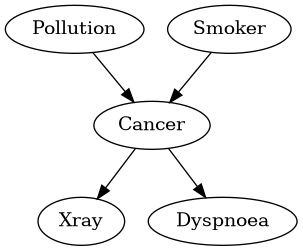

In [51]:
# Visualize the model (requires pygraphviz to be installed).
_ = tpgpguti.draw_pgmpy_model(model)

## Primitive 4: `DAG` (Structure-Only)

**Mental model**: A causal graph with no quantitative parameters.
- Only the directed graph structure is present
- No CPDs, no probability tables
- Used for causal identification, d-separation checks, and reasoning about structure
- Cannot do inference or sampling

In [21]:
# Load a structure-only DAG.
model = load_model('dagitty/confounding')

print(f"Model: {model}")
print(f"Type: {type(model).__name__}")
print(f"Nodes: {sorted(model.nodes())}")
print(f"Edges: {sorted(model.edges())}")

confounding.txt:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model: DAG with 5 nodes and 7 edges
Type: DAG
Nodes: ['A', 'B', 'D', 'E', 'Z']
Edges: [('A', 'E'), ('A', 'Z'), ('B', 'D'), ('B', 'Z'), ('E', 'D'), ('Z', 'D'), ('Z', 'E')]


In [22]:
# Confirm no CPDs available.
try:
    cpds = model.get_cpds()
    print(f"get_cpds() returned: {cpds}")
except AttributeError as e:
    print(f"No CPDs: DAG has no CPD methods.")
    print(f"  Only DiscreteBayesianNetwork has CPDs.")

No CPDs: DAG has no CPD methods.
  Only DiscreteBayesianNetwork has CPDs.


In [23]:
# Structure analysis works on DAGs.
print(f"Is directed: {model.is_directed()}")
print(f"Parents of 'A': {list(model.predecessors('A'))}")
print(f"Children of 'Z': {list(model.successors('Z'))}")
print(f"All ancestors of 'D': {model.get_ancestors('D')}")
print(f"Root nodes (no parents): {model.get_roots()}")

Is directed: True
Parents of 'A': []
Children of 'Z': ['D', 'E']
All ancestors of 'D': {'A', 'B', 'D', 'E', 'Z'}
Root nodes (no parents): ['A', 'B']


In [24]:
# DAGs support d-separation checks: are variables independent conditional on others?
print(f"A and B d-connected? {model.is_dconnected('A', 'B')}")
print(f"A and B d-separated given Z? {model.is_dconnected('A', 'B', observed='Z')}")

A and B d-connected? False
A and B d-separated given Z? True


In [25]:
# Get conditional independences implied by the graph structure.
from pgmpy.base import DAG

independencies = model.get_independencies()
assertions = independencies.get_assertions()
print(f"Number of implied independencies: {len(assertions)}")
print(f"Sample independencies:")
for assertion in assertions[:5]:
    print(f"  ({assertion.event1}) _|_ ({assertion.event2}) | ({assertion.event3})")

Number of implied independencies: 3
Sample independencies:
  (frozenset({'B'})) _|_ (frozenset({'E'})) | (frozenset({'A', 'Z'}))
  (frozenset({'A'})) _|_ (frozenset({'B'})) | (frozenset())
  (frozenset({'A'})) _|_ (frozenset({'D'})) | (frozenset({'B', 'E', 'Z'}))


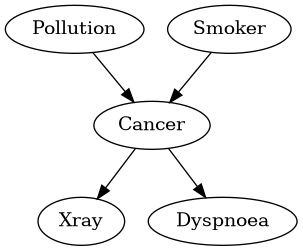

In [52]:
# Visualize the DAG.
_ = tpgpguti.draw_pgmpy_model(model)

### Subtypes: `dagitty/mediator` (Mediation Pattern)

In [27]:
# Mediator: X -> I -> Y, with Z confounder of I and X.
model_m = load_model('dagitty/mediator')
print(f"Mediator model nodes: {sorted(model_m.nodes())}")
print(f"Mediator model edges: {sorted(model_m.edges())}")

# The mediator pattern: X affects Y through I (the mediator).
print(f"\nIs X and Y d-connected? {model_m.is_dconnected('X', 'Y')}")
print(f"Is X and Y d-separated given I? {model_m.is_dconnected('X', 'Y', observed='I')}")

Mediator model nodes: ['I', 'X', 'Y', 'Z']
Mediator model edges: [('I', 'Y'), ('X', 'I'), ('X', 'Y'), ('Z', 'I'), ('Z', 'X')]

Is X and Y d-connected? True
Is X and Y d-separated given I? True


### Subtypes: `dagitty/m_bias` (M-Bias Pattern)

In [28]:
# M-bias: two independent causes (u_D_Z, u_E_Z) both affect a collider Z.
model_mb = load_model('dagitty/m_bias')
print(f"M-bias model nodes: {sorted(model_mb.nodes())}")
print(f"M-bias model edges: {sorted(model_mb.edges())}")

# Classic M-bias: conditioning on Z opens a path between D and E.
print(f"\nD and E d-connected unconditionally? {model_mb.is_dconnected('D', 'E')}")
print(f"D and E d-connected given Z? {model_mb.is_dconnected('D', 'E', observed='Z')}")

M-bias.txt:   0%|          | 0.00/178 [00:00<?, ?B/s]

M-bias model nodes: ['D', 'E', 'Z', 'u_D_Z', 'u_E_Z']
M-bias model edges: [('E', 'D'), ('u_D_Z', 'D'), ('u_D_Z', 'Z'), ('u_E_Z', 'E'), ('u_E_Z', 'Z')]

D and E d-connected unconditionally? True
D and E d-connected given Z? True


## Primitive 5: `LinearGaussianBayesianNetwork` (Continuous)

**Mental model**: A continuous-variable Bayesian network where:
- Each node follows a linear Gaussian distribution conditional on its parents
- Parameters are mean and variance (linear combination of parent values)
- Suitable for continuous data modeling and Gaussian inference
- Typically larger networks (many nodes)

In [29]:
# Load a small continuous model.
cont_models = list_models(is_continuous=True)
print(f"Continuous models available: {len(cont_models)}")
print(f"  {cont_models[:5]}")

Continuous models available: 19
  ['bnlearn/arth150', 'bnlearn/ecoli70', 'bnlearn/magic_irri', 'bnlearn/magic_niab', 'bnrep/algal2']


In [30]:
# Load one continuous model.
model_cont = load_model(cont_models[4])
print(f"Model: {cont_models[4]}")
print(f"Type: {type(model_cont).__name__}")
print(f"Number of nodes: {len(model_cont.nodes())}")
print(f"Number of edges: {len(model_cont.edges())}")

algal2.json:   0%|          | 0.00/1.90k [00:00<?, ?B/s]

Model: bnrep/algal2
Type: LinearGaussianBayesianNetwork
Number of nodes: 9
Number of edges: 9


# Part 3: Composition Examples

## Example 1: List a Category, Load a Model, Inspect Structure

Minimal workflow: discover -> load -> explore.

In [31]:
# Discover small discrete models.
tiny = list_models(is_discrete=True, is_parameterized=True, n_nodes=[4, 5, 6])
print(f"Small discrete parameterized models: {tiny}")

# Load the first one.
model = load_model(tiny[0])
print(f"\nName: {tiny[0]}")
print(f"Nodes: {sorted(model.nodes())}")
print(f"Edges: {sorted(model.edges())}")
print(f"CPDs: {len(model.get_cpds())}")

Small discrete parameterized models: ['bnlearn/cancer', 'bnlearn/earthquake', 'bnlearn/survey', 'bnrep/adversarialbehavior', 'bnrep/agropastoral5', 'bnrep/algorithms3', 'bnrep/algorithms4', 'bnrep/augmenting', 'bnrep/bank', 'bnrep/beam1', 'bnrep/beam2', 'bnrep/beatles', 'bnrep/bullet', 'bnrep/chds', 'bnrep/compaction', 'bnrep/conasense', 'bnrep/concrete1', 'bnrep/concrete2', 'bnrep/concrete4', 'bnrep/concrete7', 'bnrep/crypto', 'bnrep/firealarm', 'bnrep/fluids1', 'bnrep/fluids2', 'bnrep/hydraulicsystem', 'bnrep/knowledge', 'bnrep/navigation', 'bnrep/perioperative', 'bnrep/phdarticles', 'bnrep/rainwater', 'bnrep/ricci', 'bnrep/rockburst', 'bnrep/sallyclark', 'bnrep/simulation', 'bnrep/softwarelogs1', 'bnrep/soil', 'bnrep/theft1', 'bnrep/theft2', 'bnrep/titanic', 'bnrep/trajectories', 'bnrep/transport', 'bnrep/tubercolosis', 'bnrep/wheat', 'bnrep/witness']

Name: bnlearn/cancer
Nodes: ['Cancer', 'Dyspnoea', 'Pollution', 'Smoker', 'Xray']
Edges: [('Cancer', 'Dyspnoea'), ('Cancer', 'Xray')

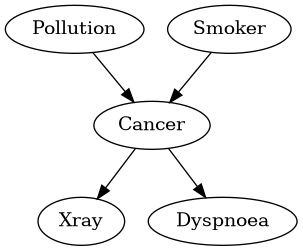

In [32]:
_ = tpgpguti.draw_pgmpy_model(model)

## Example 2: Compare Parameterized vs Structure-Only Models

Load two models and compare their capabilities.

In [ ]:
# Discrete Bayesian network (parameterized).
bn = load_model('bnlearn/cancer')
# Structure-only DAG.
dag = load_model('dagitty/confounding')

# Build a comparison DataFrame.
comparison_df = pd.DataFrame(
    {
        "Property": ["Type", "Nodes", "Edges", "Has CPDs", "Can do inference", "Parents(X)"],
        "bnlearn/cancer (BN)": [
            type(bn).__name__,
            str(len(bn.nodes())),
            str(len(bn.edges())),
            "Yes",
            "Yes",
            str(bn.get_parents("Cancer")),
        ],
        "dagitty/confounding (DAG)": [
            type(dag).__name__,
            str(len(dag.nodes())),
            str(len(dag.edges())),
            "No",
            "No (structure only)",
            str(dag.get_parents("A")),
        ],
    }
)
display(comparison_df)

## Example 3: Use a DAG for Causal Structure Analysis

Load the Asia DAG (a classic model from Lauritzen and Spiegelhalter, 1988)
to analyze its causal structure.

In [34]:
# The Asia network: a model about tuberculosis, lung cancer, and bronchitis.
asia = load_model('bnlearn/asia')

print(f"Asia network: {len(asia.nodes())} nodes, {len(asia.edges())} edges")
print(f"\nNodes: {sorted(asia.nodes())}")
print(f"Edges: {sorted(asia.edges())}")

discrete/asia.bif.gz:   0%|          | 0.00/310 [00:00<?, ?B/s]

Asia network: 8 nodes, 8 edges

Nodes: ['asia', 'bronc', 'dysp', 'either', 'lung', 'smoke', 'tub', 'xray']
Edges: [('asia', 'tub'), ('bronc', 'dysp'), ('either', 'dysp'), ('either', 'xray'), ('lung', 'either'), ('smoke', 'bronc'), ('smoke', 'lung'), ('tub', 'either')]


In [35]:
# Analyze the causal structure.
print(f"Root nodes: {asia.get_roots()}")
print(f"Leaf nodes: {asia.get_leaves()}")
print(f"Markov blanket of 'lung': {asia.get_markov_blanket('lung')}")
print(f"Active trail from 'smoke' to 'dysp': {asia.is_dconnected('smoke', 'dysp')}")
print(f"Does 'tub' d-separate 'asia' from 'either'?: {asia.is_dconnected('asia', 'either', observed='tub')}")

Root nodes: ['asia', 'smoke']
Leaf nodes: ['xray', 'dysp']
Markov blanket of 'lung': ['either', 'smoke', 'tub']
Active trail from 'smoke' to 'dysp': True
Does 'tub' d-separate 'asia' from 'either'?: False


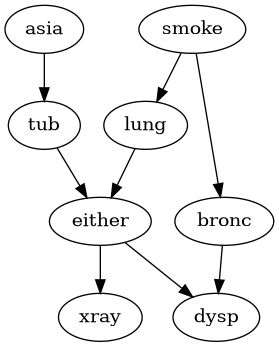

In [36]:
_ = tpgpguti.draw_pgmpy_model(asia)

## Example 4: Use a Parameterized Model for Inference

Load the Earthquake (Burglar Alarm) network and perform inference queries.

In [37]:
from pgmpy.inference import VariableElimination

# Load the classic Burglar Alarm model.
alarm = load_model('bnlearn/earthquake')
print(f"Earthquake model: {len(alarm.nodes())} nodes, {len(alarm.edges())} edges")
print(f"Nodes: {sorted(alarm.nodes())}")
print(f"Edges: {sorted(alarm.edges())}")

discrete/earthquake.bif.gz:   0%|          | 0.00/271 [00:00<?, ?B/s]

Earthquake model: 5 nodes, 4 edges
Nodes: ['Alarm', 'Burglary', 'Earthquake', 'JohnCalls', 'MaryCalls']
Edges: [('Alarm', 'JohnCalls'), ('Alarm', 'MaryCalls'), ('Burglary', 'Alarm'), ('Earthquake', 'Alarm')]


In [38]:
# View the CPDs.
for cpd in alarm.get_cpds():
    print(cpd)

+--------------+------------------+-----+-------------------+
| Burglary     | Burglary(True)   | ... | Burglary(False)   |
+--------------+------------------+-----+-------------------+
| Earthquake   | Earthquake(True) | ... | Earthquake(False) |
+--------------+------------------+-----+-------------------+
| Alarm(True)  | 0.95             | ... | 0.001             |
+--------------+------------------+-----+-------------------+
| Alarm(False) | 0.05             | ... | 0.999             |
+--------------+------------------+-----+-------------------+
+-----------------+------+
| Burglary(True)  | 0.01 |
+-----------------+------+
| Burglary(False) | 0.99 |
+-----------------+------+
+-------------------+------+
| Earthquake(True)  | 0.02 |
+-------------------+------+
| Earthquake(False) | 0.98 |
+-------------------+------+
+------------------+-------------+--------------+
| Alarm            | Alarm(True) | Alarm(False) |
+------------------+-------------+--------------+
| JohnCalls(

In [39]:
# Perform inference: given John calls, what is P(Burglary)?
# Note: state names are strings ('True', 'False'), not integers.
inference = VariableElimination(alarm)
result = inference.query(variables=['Burglary'], evidence={'JohnCalls': 'True'})
print("P(Burglary | JohnCalls=True):")
print(result)

P(Burglary | JohnCalls=True):
+-----------------+-----------------+
| Burglary        |   phi(Burglary) |
+=================+=================+
| Burglary(True)  |          0.1333 |
+-----------------+-----------------+
| Burglary(False) |          0.8667 |
+-----------------+-----------------+


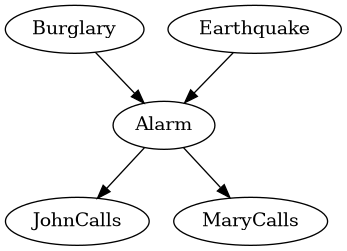

In [40]:
_ = tpgpguti.draw_pgmpy_model(alarm)

# Part 4: API Patterns

## 1. Catalog-Load Pattern

The dominant pattern: `list_models()` (discover) -> `load_model()` (fetch).
This is similar to `sklearn.datasets.fetch_*` or `torchvision.datasets`.

In [41]:
# The pattern in one line.
model = load_model(list_models(is_discrete=True, n_nodes=5)[0])
print(f"Loaded: {model}")

Loaded: DiscreteBayesianNetwork named 'unknown' with 5 nodes and 4 edges


## 2. Filter Criterion Pattern

Filters are keyword arguments that function as predicates on model metadata.
Multiple filters combine with AND semantics.

In [42]:
# AND-combined filters: discrete AND small.
small_discrete = list_models(is_discrete=True, n_nodes=[4, 5, 6])
print(f"Small discrete models ({len(small_discrete)}): {small_discrete}")

Small discrete models (44): ['bnlearn/cancer', 'bnlearn/earthquake', 'bnlearn/survey', 'bnrep/adversarialbehavior', 'bnrep/agropastoral5', 'bnrep/algorithms3', 'bnrep/algorithms4', 'bnrep/augmenting', 'bnrep/bank', 'bnrep/beam1', 'bnrep/beam2', 'bnrep/beatles', 'bnrep/bullet', 'bnrep/chds', 'bnrep/compaction', 'bnrep/conasense', 'bnrep/concrete1', 'bnrep/concrete2', 'bnrep/concrete4', 'bnrep/concrete7', 'bnrep/crypto', 'bnrep/firealarm', 'bnrep/fluids1', 'bnrep/fluids2', 'bnrep/hydraulicsystem', 'bnrep/knowledge', 'bnrep/navigation', 'bnrep/perioperative', 'bnrep/phdarticles', 'bnrep/rainwater', 'bnrep/ricci', 'bnrep/rockburst', 'bnrep/sallyclark', 'bnrep/simulation', 'bnrep/softwarelogs1', 'bnrep/soil', 'bnrep/theft1', 'bnrep/theft2', 'bnrep/titanic', 'bnrep/trajectories', 'bnrep/transport', 'bnrep/tubercolosis', 'bnrep/wheat', 'bnrep/witness']


## 3. Model Type Dispatch Pattern

`load_model()` returns different types depending on the model.
You can check the type and adapt your code:

In [43]:
# Dispatch on model type.
def describe_model(name):
    """
    Load a model by name and print type-specific information.
    """
    model = load_model(name)
    print(f"\nModel: {name}")
    print(f"  Type: {type(model).__name__}")
    print(f"  Nodes: {len(model.nodes())}, Edges: {len(model.edges())}")

    if hasattr(model, 'get_cpds'):
        cpds = model.get_cpds()
        print(f"  CPDs: {len(cpds)}")
        for cpd in cpds[:3]:
            print(f"    {cpd.variable}: card={cpd.variable_card}")
        if len(cpds) > 3:
            print(f"    ... and {len(cpds) - 3} more CPDs")

# Test with different model types.
describe_model('bnlearn/cancer')
describe_model('dagitty/confounding')
describe_model('bnlearn/sachs')


Model: bnlearn/cancer
  Type: DiscreteBayesianNetwork
  Nodes: 5, Edges: 4
  CPDs: 5
    Cancer: card=2
    Dyspnoea: card=2
    Pollution: card=2
    ... and 2 more CPDs

Model: dagitty/confounding
  Type: DAG
  Nodes: 5, Edges: 7


discrete/sachs.bif.gz:   0%|          | 0.00/1.92k [00:00<?, ?B/s]


Model: bnlearn/sachs
  Type: DiscreteBayesianNetwork
  Nodes: 11, Edges: 17
  CPDs: 11
    Akt: card=3
    Erk: card=3
    Jnk: card=3
    ... and 8 more CPDs


# Part 5: Interactive Exploration

## Experiment 1: What Happens If You Filter with Conflicting Flags?

In [45]:
# Explore filter behavior.
print("is_discrete=True + is_continuous=True -> AND semantics")
both = list_models(is_discrete=True, is_continuous=True)
print(f"  Result: {len(both)} models (a model can't be both discrete and continuous)")
print(f"  Models: {both}")

print("\nis_parameterized=True + is_discrete=True")
both2 = list_models(is_parameterized=True, is_discrete=True)
print(f"  Result: {len(both2)} models (parameterized discrete models)")

is_discrete=True + is_continuous=True -> AND semantics
  Result: 0 models (a model can't be both discrete and continuous)
  Models: []

is_parameterized=True + is_discrete=True
  Result: 226 models (parameterized discrete models)


## Experiment 3: Inspect a Large Model (Sachs)

In [47]:
# Load the Sachs protein signaling network (a benchmark model).
sachs = load_model('bnlearn/sachs')
print(f"Sachs network: {len(sachs.nodes())} nodes, {len(sachs.edges())} edges")
print(f"Nodes: {sorted(sachs.nodes())}")
print(f"Edges: {sorted(sachs.edges())}")

# Check state counts (some variables have more than 2 states).
print(f"\nVariable cardinalities:")
for node in sorted(sachs.nodes()):
    cpd = sachs.get_cpds(node)
    print(f"  {node}: {cpd.variable_card} states")

Sachs network: 11 nodes, 17 edges
Nodes: ['Akt', 'Erk', 'Jnk', 'Mek', 'P38', 'PIP2', 'PIP3', 'PKA', 'PKC', 'Plcg', 'Raf']
Edges: [('Erk', 'Akt'), ('Mek', 'Erk'), ('PIP3', 'PIP2'), ('PKA', 'Akt'), ('PKA', 'Erk'), ('PKA', 'Jnk'), ('PKA', 'Mek'), ('PKA', 'P38'), ('PKA', 'Raf'), ('PKC', 'Jnk'), ('PKC', 'Mek'), ('PKC', 'P38'), ('PKC', 'PKA'), ('PKC', 'Raf'), ('Plcg', 'PIP2'), ('Plcg', 'PIP3'), ('Raf', 'Mek')]

Variable cardinalities:
  Akt: 3 states
  Erk: 3 states
  Jnk: 3 states
  Mek: 3 states
  P38: 3 states
  PIP2: 3 states
  PIP3: 3 states
  PKA: 3 states
  PKC: 3 states
  Plcg: 3 states
  Raf: 3 states


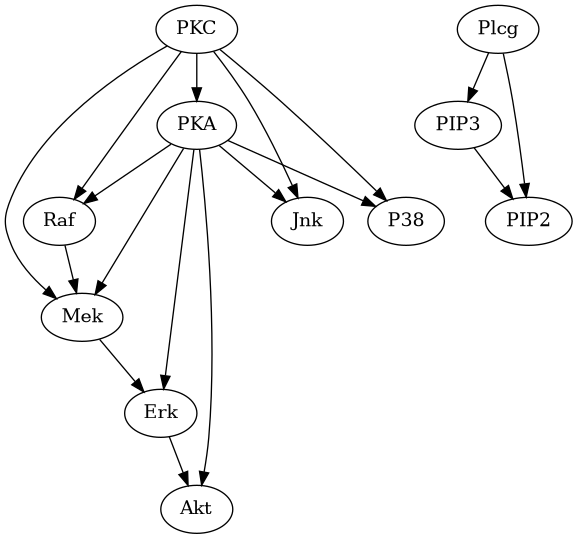

In [48]:
_ = tpgpguti.draw_pgmpy_model(sachs)

## Experiment 4: Explore the Model API with `dir()`

In [49]:
# Use dir() to see what methods are available on a model.
model = load_model('bnlearn/cancer')
methods = [m for m in dir(model) if not m.startswith('_')]
print(f"Methods on DiscreteBayesianNetwork ({len(methods)}):")

# Group by category.
graph_methods = [m for m in methods if any(
    x in m for x in ['edge', 'node', 'graph', 'parent', 'child', 'ancestor',
                      'neighbor', 'root', 'leaf', 'successor', 'predecessor']
)]
inference_methods = [m for m in methods if any(
    x in m for x in ['cpd', 'factor', 'markov', 'moral', 'independ',
                      'dconnec', 'simul', 'predict']
)]
other = [m for m in methods if m not in graph_methods + inference_methods]

print(f"\n  Graph structure methods: {sorted(graph_methods)}")
print(f"\n  Inference/CPD methods: {sorted(inference_methods)}")
print(f"\n  Other methods: {sorted(other)}")

Methods on DiscreteBayesianNetwork (114):

  Graph structure methods: ['active_trail_nodes', 'add_edge', 'add_edges_from', 'add_node', 'add_nodes_from', 'add_weighted_edges_from', 'clear_edges', 'edge_attr_dict_factory', 'edge_strength', 'edge_subgraph', 'edges', 'get_ancestors', 'get_ancestral_graph', 'get_children', 'get_edge_data', 'get_parents', 'get_roots', 'graph', 'graph_attr_dict_factory', 'has_edge', 'has_node', 'has_predecessor', 'has_successor', 'in_edges', 'is_multigraph', 'neighbors', 'node_attr_dict_factory', 'node_dict_factory', 'nodes', 'number_of_edges', 'number_of_nodes', 'out_edges', 'predecessors', 'remove_edge', 'remove_edges_from', 'remove_node', 'remove_nodes_from', 'subgraph', 'successors', 'to_graphviz']

  Inference/CPD methods: ['add_cpds', 'adjlist_inner_dict_factory', 'adjlist_outer_dict_factory', 'cpds', 'edge_attr_dict_factory', 'get_cpds', 'get_factorized_product', 'get_immoralities', 'get_independencies', 'get_markov_blanket', 'get_random_cpds', 'graph_

# Summary: The Mental Model

- **`list_models(**filters)`**: "Show me which pre-built models are available"
  - Filters by type (`is_discrete`, `is_continuous`, `is_hybrid`, `is_parameterized`)
  - Filters by size (`n_nodes`, `n_edges`) with exact int or list of ints
  - Returns a list of `repository/name` strings

- **`load_model(name)`**: "Fetch that model by name"
  - Returns `DiscreteBayesianNetwork` (parameterized, discrete, with CPDs) for bnlearn/bnrep
  - Returns `DAG` (structure-only, no parameters) for dagitty
  - Returns `LinearGaussianBayesianNetwork` (continuous) for some models

- **Three model types**, one unified discovery API:
  - Parameterized discrete models: ready for `VariableElimination`, `predict()`, `simulate()`
  - Structure-only DAGs: ready for `is_dconnected()`, `get_independencies()`, causal reasoning
  - Continuous models: ready for Gaussian inference
  - All share `nodes()`, `edges()`, `get_parents()`, `to_graphviz()`, and other graph methods